In [54]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import accuracy_score



In [55]:
df=pd.read_csv("ice_temp.csv")
df.head()

,Temperature,Ice Cream Profits
0,39,13.17
1,40,11.88
2,41,18.82
3,42,18.65
4,43,17.02


In [56]:
df['Profits']=df['Ice Cream Profits']
df.drop('Ice Cream Profits',axis=1,inplace=True)
df.head()

,Temperature,Profits
0,39,13.17
1,40,11.88
2,41,18.82
3,42,18.65
4,43,17.02


In [57]:
X_train, X_test, y_train, y_test = train_test_split(df[['Temperature']], df["Profits"], test_size=0.2, random_state=42)

In [58]:
X_train.head()

,Temperature
211,76
340,91
202,75
75,61
84,62


In [59]:
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [60]:
# 5. Train the model using Linear Regression
model = LinearRegression()
model.fit(X_train_poly, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [61]:
y_test_pred = model.predict(X_test_poly)

Mean Squared Error: 5.226164484407723
R² Score: 0.9838284274879107


/home/roshan-singh/All_Code/projects/ML/mlvenv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


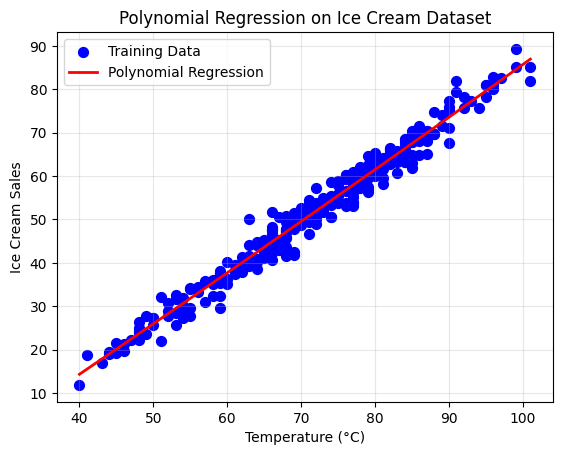

In [62]:
# 7. Create smooth curve for visualization
X_range = np.linspace(X_train.min(), X_train.max(), 100).reshape(-1, 1)
X_range_poly = poly.transform(X_range)
y_range_pred = model.predict(X_range_poly)
print("Mean Squared Error:", mean_squared_error(y_test, y_test_pred))
print("R² Score:", r2_score(y_test, y_test_pred))

# Plot the training data
plt.scatter(X_train, y_train, color='blue', label='Training Data', s=50)

# Plot the polynomial regression curve
plt.plot(X_range, y_range_pred, color='red', linewidth=2, label='Polynomial Regression')

plt.xlabel("Temperature (°C)")
plt.ylabel("Ice Cream Sales")
plt.title("Polynomial Regression on Ice Cream Dataset")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [63]:
df2=pd.read_csv("cars_fuel_efficiency_clean.csv")
df2.head()

,trip_id,car_name,vehicle_type,fuel_type,trip_category,distance_km,trip_duration_hr,avg_speed_kmph,base_mileage_kmpl,actual_mileage_kmpl,mileage_delta_kmpl,fuel_consumed_L,fuel_cost_usd,cost_per_km_usd,co2_emissions_kg,co2_per_km,relative_efficiency,efficiency_band
0,1,Lexus ES,Luxury,Diesel,Very Long (>400 km),437.85,4.84,90.51,11.31,11.24,-0.07,38.96,44.59,0.1018,104.413,0.2385,0.5979,Average
1,2,Lexus ES,Luxury,Petrol,Medium (50–200 km),181.86,3.54,51.43,9.98,9.61,-0.37,18.92,23.93,0.1316,43.705,0.2403,0.5113,Poor
2,3,Audi A6,Luxury,Petrol,Medium (50–200 km),118.07,1.46,80.62,11.06,11.24,0.18,10.50,13.28,0.1125,24.255,0.2054,0.5982,Average
3,4,Maruti Swift,Hatchback,Diesel,Long (200–400 km),343.16,4.72,72.65,21.17,19.65,-1.52,17.46,19.98,0.0582,46.793,0.1364,0.7181,Average
4,5,Hyundai Creta,SUV,Diesel,Long (200–400 km),371.03,3.87,95.78,13.01,12.39,-0.62,29.95,34.28,0.0924,80.266,0.2163,0.5717,Average


In [64]:
x=df2['avg_speed_kmph']
y=df2['actual_mileage_kmpl']
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [65]:
poly = PolynomialFeatures(degree=3)  # Higher degree for more visible curvature
X_train_poly = poly.fit_transform(X_train.values.reshape(-1, 1))
X_test_poly = poly.transform(X_test.values.reshape(-1, 1))

In [66]:
# 5. Train the model using Linear Regression
model = LinearRegression()
model.fit(X_train_poly, y_train)
y_test_pred = model.predict(X_test_poly)

Mean Squared Error: 14.23379485554836
R² Score: -0.03633501658036975


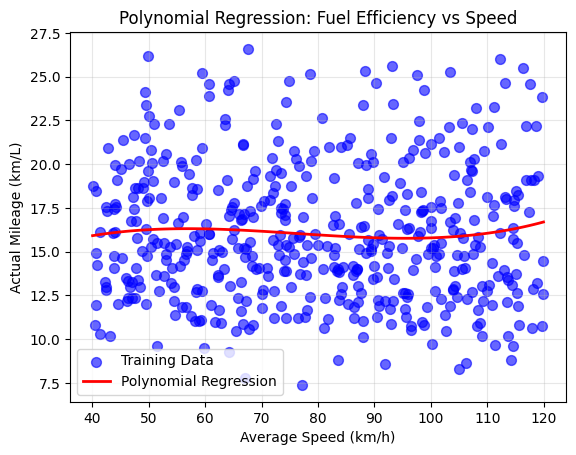

In [67]:
# 7. Create smooth curve for visualization
X_range = np.linspace(X_train.min(), X_train.max(), 100).reshape(-1, 1)
X_range_poly = poly.transform(X_range)
y_range_pred = model.predict(X_range_poly)
print("Mean Squared Error:", mean_squared_error(y_test, y_test_pred))
print("R² Score:", r2_score(y_test, y_test_pred))

# Plot the training data
plt.scatter(X_train, y_train, color='blue', label='Training Data', s=50, alpha=0.6)

# Plot the polynomial regression curve
plt.plot(X_range, y_range_pred, color='red', linewidth=2, label='Polynomial Regression')

plt.xlabel("Average Speed (km/h)")
plt.ylabel("Actual Mileage (km/L)")
plt.title("Polynomial Regression: Fuel Efficiency vs Speed")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()